In [1]:
import sys
import os
import numpy as np
import torch
import tensorflow
import matplotlib.pyplot as plt
import warnings
import pickle
import gc
warnings.filterwarnings("ignore")

# Get the absolute path of the folder containing your notebook
current_path = os.path.abspath(os.getcwd())

# Force Python to look here first
if current_path not in sys.path:
    sys.path.insert(0, current_path)

print(f"Python is now looking in: {current_path}")

from options import Options

# 1. TimeGAN model
from lib.timegan import TimeGAN
# 2. Data loading
from lib.data import real_data_loading, sine_data_generation

2026-05-08 13:18:48.958351: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-05-08 13:18:48.958386: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


Python is now looking in: /home/tunabeluga/ECE479/TimeGAN-pytorch


In [2]:
if torch.cuda.is_available():
    DEVICE = "cuda"
    print("Using GPU:", torch.cuda.get_device_name(0))
    print("PyTorch CUDA version:", torch.version.cuda)
else:
    DEVICE = "cpu"
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 2070 SUPER
PyTorch CUDA version: 12.1


### Parameters

For stock data, the feature dimension is fixed by the CSV columns. For sine data, the feature dimension is manually chosen.

#### Stock data

- `data_name = "stock"`
- `seq_len = 24` — each sample contains 24 trading days
- `z_dim = 6` — matches the 6 stock features
- `hidden_dim = 24` — internal model width
- `num_layer = 3` — number of recurrent layers
- `batch_size = 128`
- `iteration = 10` for debugging, `5000+` for actual training
- `metric_iteration = 1` for debugging, `5–10` for final evaluation
  
#### Transformer parameters

- `encoder_type = "transformer"` or `"rnn"`
- `discriminator_type = "transformer"` or `"rnn"`
- `d_model = 24` — transformer embedding size
- `nhead = 4` — must divide `d_model`
- `dim_feedforward = 96` — usually `4 * d_model`
- `dropout = 0.1`
- `max_seq_len = 24` — should match `seq_len`

These parameters were derived from the original TimeGAN tutorial notebook. I kept them for replication + simplicity purposes.

### Notes: 
For debugging and testing purposes:

In `discriminative_metrics.py`, iterations = 100. When actually running, use iterations = 10000

In `predictive_metrics.py`, iterations = 100. When actually running, use iterations = 5000


In [3]:
# Data Generation + Loading

# Synthetic Sine Data
'''
no = amount of synthetic time-series samples
seq_len = the number of time steps in each sample
dim = 5 sine-wave features
'''
# sine_data = sine_data_generation(no=10000, seq_len=24, dim=5)

# Real Stock Data 
stock_data = real_data_loading("stock", 24) # Load stock data as rolling sequences of length 24, each with 6 features


In [4]:
# TimeGAN Model Selection + Parameters 

num_gen = min(1000, len(stock_data)) # Number of final generated samples (for plotting)

def make_opt(name, encoder_type="rnn", discriminator_type="rnn",
             iteration=1000, metric_iteration=5, device=DEVICE):
    sys.argv = [
        "notebook",
        "--data_name", "stock",
        "--seq_len", "24",
        "--z_dim", "6",
        "--hidden_dim", "24",
        "--num_layer", "3",
        "--iteration", str(iteration),
        "--batch_size", "128",
        "--metric_iteration", str(metric_iteration),
        "--device", device,
        "--encoder_type", encoder_type,
        "--discriminator_type", discriminator_type,
        "--d_model", "24",
        "--nhead", "4",
        "--dim_feedforward", "96",
        "--dropout", "0.1",
        "--max_seq_len", "24",
        "--name", name
    ]

    return Options().parse()

In [5]:
# Save results after model runs

os.makedirs("saved_results", exist_ok=True)

def save_generated(name, generated_data):
    path = f"saved_results/{name}_generated.pkl"
    with open(path, "wb") as f:
        pickle.dump(generated_data, f)
    print(f"Saved {len(generated_data)} generated samples to {path}")

def load_generated(name):
    path = f"saved_results/{name}_generated.pkl"
    with open(path, "rb") as f:
        return pickle.load(f)

def cleanup_model(model):
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Cleared model from memory.")

In [6]:
# Generate More Data for Plotting

def generate_more_data(model, num_samples):
    generated = []

    while len(generated) < num_samples:
        batch = model.generation(model.opt.batch_size)
        generated.extend(batch)

    return generated[:num_samples]

In [7]:
# Original TimeGAN
opt_TimeGAN = make_opt(
    name="stock_original_rnn_rnn",
    encoder_type="rnn",
    discriminator_type="rnn",
    iteration=10000,
    device=DEVICE
)

In [8]:
# TimeGAN w/ Transformer Encoder
opt_encoder_transformer = make_opt(
    name="stock_transformer_encoder_rnn_discriminator",
    encoder_type="transformer",
    discriminator_type="rnn",
    iteration=10000,
    device=DEVICE
)

In [9]:
# TimeGAN w/ Transformer Discriminator
opt_discriminator_transformer = make_opt(
    name="stock_rnn_encoder_transformer_discriminator",
    encoder_type="rnn",
    discriminator_type="transformer",
    iteration=10000,
    device=DEVICE
)

In [10]:
# TimeGAN w/ Transformer Encoder and Transformer Discriminator
opt_both_transformer = make_opt(
    name="stock_transformer_encoder_transformer_discriminator",
    encoder_type="transformer",
    discriminator_type="transformer",
    iteration=10000,
    device=DEVICE
)

In [11]:
model_original = TimeGAN(opt_TimeGAN, stock_data)
model_original.train()
generated_original = model_original.generated_data

print("="*80)
generated_original_1000 = generate_more_data(model_original, num_gen)
save_generated("stock_original_rnn_rnn", generated_original_1000)

cleanup_model(model_original)

step: 0/10000, e_loss: 0.0989
step: 1000/10000, e_loss: 0.0006
step: 2000/10000, e_loss: 0.0003
step: 3000/10000, e_loss: 0.0001
step: 4000/10000, e_loss: 0.0001
step: 5000/10000, e_loss: 0.0000
step: 6000/10000, e_loss: 0.0000
step: 7000/10000, e_loss: 0.0000
step: 8000/10000, e_loss: 0.0000
step: 9000/10000, e_loss: 0.0000
Finish Embedding Network Training
step: 0/10000, s_loss: 0.0405
step: 1000/10000, s_loss: 0.0003
step: 2000/10000, s_loss: 0.0002
step: 3000/10000, s_loss: 0.0003
step: 4000/10000, s_loss: 0.0003
step: 5000/10000, s_loss: 0.0003
step: 6000/10000, s_loss: 0.0002
step: 7000/10000, s_loss: 0.0002
step: 8000/10000, s_loss: 0.0003
step: 9000/10000, s_loss: 0.0003
Finish Training with Supervised Loss Only
step: 0/10000, joint training
step: 1000/10000, joint training
step: 2000/10000, joint training
step: 3000/10000, joint training
step: 4000/10000, joint training
step: 5000/10000, joint training
step: 6000/10000, joint training
step: 7000/10000, joint training
step: 800

In [12]:
# model_encoder_transformer = TimeGAN(opt_encoder_transformer, stock_data)
# model_encoder_transformer.train()
# generated_encoder_transformer = model_encoder_transformer.generated_data

# print("="*80)
# generated_encoder_transformer_1000 = generate_more_data(model_encoder_transformer, num_gen)
# save_generated("stock_transformer_encoder_rnn_discriminator", generated_encoder_transformer_1000)

# cleanup_model(model_encoder_transformer)

In [13]:
# model_discriminator_transformer = TimeGAN(opt_discriminator_transformer, stock_data)
# model_discriminator_transformer.train()
# generated_discriminator_transformer = model_discriminator_transformer.generated_data

# print("="*80)
# generated_discriminator_transformer_1000 = generate_more_data(model_discriminator_transformer, num_gen)
# save_generated("stock_rnn_encoder_transformer_discriminator", generated_discriminator_transformer_1000)

# cleanup_model(model_discriminator_transformer)

In [14]:
# model_both_transformer = TimeGAN(opt_both_transformer, stock_data)
# model_both_transformer.train()
# generated_both_transformer = model_both_transformer.generated_data

# print("="*80)
# generated_both_transformer_1000 = generate_more_data(model_both_transformer, num_gen)
# save_generated("stock_transformer_encoder_transformer_discriminator", generated_both_transformer_1000)

# cleanup_model(model_both_transformer)

In [15]:
# %%capture
# # Call and Train the Model on Sine data

# model_sine = TimeGAN(opt, sine_data)
# model_sine.train()

In [16]:
# Evaluation of Generated Data:
from lib.metrics.discriminative_metrics import discriminative_score_metrics
from lib.metrics.predictive_metrics import predictive_score_metrics
from lib.metrics.visualization_metrics import visualization

In [17]:
# Generate More Data for Plotting
generated_results_1000 = {
    "Original TimeGAN": generated_original_1000,
    # "Transformer Encoder": generated_encoder_transformer_1000,
    # "Transformer Discriminator": generated_discriminator_transformer_1000,
    # "Transformer Encoder + Discriminator": generated_both_transformer_1000,
}

for name, gen_data in generated_results_1000.items():
    print(name, np.asarray(gen_data).shape)

Original TimeGAN (1000, 24, 6)


In [18]:
# Evaluation of Generated Data:
generated_results = {
    "Original TimeGAN": generated_original,
    # "Transformer Encoder": generated_encoder_transformer,
    # "Transformer Discriminator": generated_discriminator_transformer,
    # "Transformer Encoder + Discriminator": generated_both_transformer,
}

metric_iteration = 5

for name, gen_data in generated_results_1000.items():
    print("=" * 80)
    print(name)
    print("=" * 80)

    n = min(len(stock_data), len(gen_data))
    stock_eval = np.asarray(stock_data)[:n]
    gen_eval = np.asarray(gen_data)[:n]

    disc_scores = []
    pred_scores = []

    for _ in range(metric_iteration):
        disc_scores.append(discriminative_score_metrics(stock_eval, gen_eval))
        pred_scores.append(predictive_score_metrics(stock_eval, gen_eval))

    print("Discriminative score:", np.mean(disc_scores), "+/-", np.std(disc_scores))
    print("Predictive score:", np.mean(pred_scores), "+/-", np.std(pred_scores))

Original TimeGAN
Instructions for updating:
Please use `keras.layers.RNN(cell)`, which is equivalent to this API
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Please use tf.global_variables instead.


2026-05-08 13:34:02.325692: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:961] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-08 13:34:02.325961: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-05-08 13:34:02.326075: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-05-08 13:34:02.326140: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-05-08 13:34:02.326204: W tensorflow/stream_executor/platform/default/dso_loader.cc:6

Discriminative score: 0.17400000000000002 +/- 0.027367864366808
Predictive score: 0.03742347885003766 +/- 0.000127289595787767


stock_data length: 3661
Visualization: Original TimeGAN


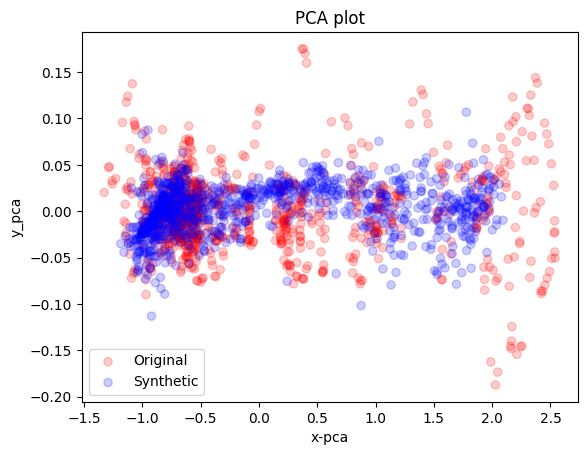

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.000s...
[t-SNE] Computed neighbors for 2000 samples in 0.101s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 0.031203
[t-SNE] KL divergence after 250 iterations with early exaggeration: 53.067932
[t-SNE] KL divergence after 300 iterations: 0.975098


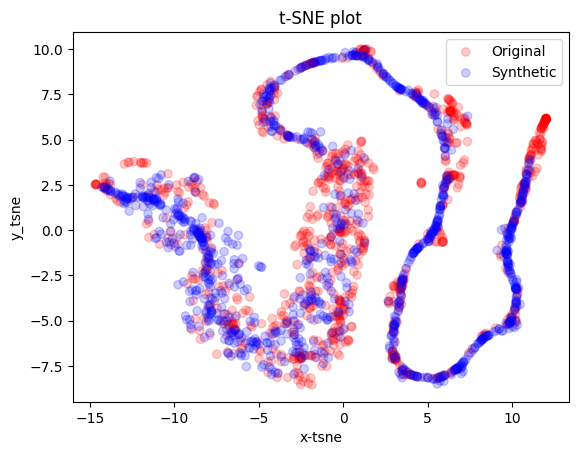

In [19]:
print("stock_data length:", len(stock_data))

for name, gen_data in generated_results_1000.items():
    print("=" * 80)
    print("Visualization:", name)
    print("=" * 80)

    n = min(len(stock_data), len(gen_data)) 
    
    stock_vis = np.asarray(stock_data)[:n]
    gen_vis = np.asarray(gen_data)[:n]
    
    visualization(stock_vis, gen_vis, "pca")
    visualization(stock_vis, gen_vis, "tsne")

In [20]:
import torch
import numpy as np

model_original.nete.eval()
model_original.netr.eval()

X = torch.tensor(model_original.ori_data[:128], dtype=torch.float32).to(model_original.device)

with torch.no_grad():
    H = model_original.nete(X)
    X_tilde = model_original.netr(H)

recon_mse = torch.mean((X_tilde - X) ** 2).item()

print("Reconstruction MSE:", recon_mse)
print("X real normalized min/max/mean/std:", X.min().item(), X.max().item(), X.mean().item(), X.std().item())
print("X_tilde min/max/mean/std:", X_tilde.min().item(), X_tilde.max().item(), X_tilde.mean().item(), X_tilde.std().item())

Reconstruction MSE: 6.156139988888754e-06
X real normalized min/max/mean/std: 0.0 0.9999998807907104 0.30403932929039 0.24883367121219635
X_tilde min/max/mean/std: 0.005451929289847612 0.9917479753494263 0.30493664741516113 0.24945704638957977


In [22]:
from utils import random_generator

model_original.nete.eval()
model_original.netg.eval()
model_original.nets.eval()
model_original.netr.eval()

X = torch.tensor(
    model_original.ori_data[:model_original.opt.batch_size],
    dtype=torch.float32
).to(model_original.device)

T = model_original.ori_time[:model_original.opt.batch_size]

Z = random_generator(
    model_original.opt.batch_size,
    model_original.opt.z_dim,
    T,
    model_original.max_seq_len
)
Z = torch.tensor(Z, dtype=torch.float32).to(model_original.device)

with torch.no_grad():
    H_real = model_original.nete(X)
    X_recon = model_original.netr(H_real)

    E_hat = model_original.netg(Z)
    H_hat = model_original.nets(E_hat)
    X_fake = model_original.netr(H_hat)

print("X real min/max/mean/std:")
print(X.min().item(), X.max().item(), X.mean().item(), X.std().item())

print("\nX_recon = netr(H_real) min/max/mean/std:")
print(X_recon.min().item(), X_recon.max().item(), X_recon.mean().item(), X_recon.std().item())

print("\nX_fake = netr(H_hat) min/max/mean/std:")
print(X_fake.min().item(), X_fake.max().item(), X_fake.mean().item(), X_fake.std().item())

X real min/max/mean/std:
0.0 0.9999998807907104 0.30403932929039 0.24883367121219635

X_recon = netr(H_real) min/max/mean/std:
0.005451929289847612 0.9917479753494263 0.30493664741516113 0.24945704638957977

X_fake = netr(H_hat) min/max/mean/std:
0.006742456927895546 0.8792868852615356 0.2653672397136688 0.2385902851819992


In [23]:
real = np.asarray(stock_data)[:1000]
fake = np.asarray(generated_original_1000)[:1000]

for q in [0, 1, 5, 25, 50, 75, 95, 99, 100]:
    print(f"{q}th percentile")
    print("Real:", np.percentile(real, q, axis=(0, 1)))
    print("Fake:", np.percentile(fake, q, axis=(0, 1)))
    print()

0th percentile
Real: [0.         0.         0.00123226 0.         0.         0.        ]
Fake: [0.00683844 0.00741406 0.00763163 0.00566117 0.00726529 0.00780525]

1th percentile
Real: [0.02796682 0.02771043 0.02816823 0.02751974 0.02751974 0.01006643]
Fake: [0.03307868 0.0330527  0.03451258 0.03307714 0.03392029 0.0116077 ]

5th percentile
Real: [0.06922173 0.07148511 0.06883001 0.06766    0.06766    0.01315971]
Fake: [0.06209703 0.06263449 0.0627193  0.0619858  0.061663   0.01437142]

25th percentile
Real: [0.155017   0.15553006 0.15678191 0.15454018 0.15454018 0.02401758]
Fake: [0.12649271 0.12714482 0.12750547 0.12617376 0.12617174 0.02173812]

50th percentile
Real: [0.20826699 0.20918043 0.21084822 0.20857685 0.20857685 0.05668425]
Fake: [0.24094035 0.24191065 0.24325726 0.24070911 0.24079186 0.04952353]

75th percentile
Real: [0.45370243 0.45534597 0.45770479 0.45298932 0.45298932 0.11554709]
Fake: [0.56245458 0.56563173 0.56839345 0.56429346 0.56439719 0.11140446]

95th percenti